# 02 — Manual Analysis: Open Coding, Axial Coding, dan Selective Coding

Notebook ini digunakan untuk melakukan analisis manual terhadap hasil chunking teks pidato Presiden Prabowo pada Sidang Umum PBB ke-80.

Analisis manual dilakukan menggunakan tiga tahapan:

1. **Open Coding**  
   Mengidentifikasi kode awal dari setiap chunk teks berdasarkan ide, isu, atau pesan utama yang muncul.

2. **Axial Coding**  
   Mengelompokkan beberapa open code yang memiliki keterkaitan makna ke dalam kategori yang lebih besar.

3. **Selective Coding**  
   Menentukan tema utama yang mewakili kategori-kategori hasil axial coding.

Tujuan tahap ini adalah menghasilkan baseline interpretatif manusia yang nantinya dapat dibandingkan dengan hasil topic modeling menggunakan BERTopic.

## 1. Import Library

Library yang digunakan pada tahap ini meliputi:

- `pandas` untuk pengolahan data tabular.
- `numpy` untuk operasi numerik sederhana.
- `pathlib` untuk pengelolaan path file.
- `re` untuk pencarian kata kunci berbasis regular expression.
- `matplotlib` untuk visualisasi distribusi tema.

In [1]:
# Import library utama
from pathlib import Path
import re
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# Pengaturan tampilan pandas agar teks chunk lebih mudah dibaca
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 120)

print("Library berhasil di-import.")

Library berhasil di-import.


## 2. Konfigurasi Path Project

Notebook ini membaca file hasil chunking dari:

`data/processed/pidato_prabowo_pbb80_chunks.csv`

Kemudian hasil manual analysis akan disimpan ke:

`data/processed/manual_analysis_results.csv`

In [2]:
# Fungsi untuk mendeteksi root folder project
def find_project_root() -> Path:
    """
    Mencari root project baik notebook dijalankan dari folder root maupun folder notebooks.
    """
    current_path = Path.cwd()

    # Jika notebook dijalankan dari root project
    if (current_path / "data").exists():
        return current_path

    # Jika notebook dijalankan dari folder notebooks
    if current_path.name == "notebooks" and (current_path.parent / "data").exists():
        return current_path.parent

    # Fallback: gunakan parent folder
    return current_path.parent


# Definisi path
PROJECT_ROOT = find_project_root()
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

INPUT_PATH = DATA_PROCESSED_DIR / "pidato_prabowo_pbb80_chunks.csv"
OUTPUT_TEMPLATE_PATH = DATA_PROCESSED_DIR / "manual_coding_template.csv"
OUTPUT_RESULT_PATH = DATA_PROCESSED_DIR / "manual_analysis_results.csv"

print("Project root:", PROJECT_ROOT)
print("Input file  :", INPUT_PATH)
print("Output file :", OUTPUT_RESULT_PATH)

# Validasi file input
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"File tidak ditemukan: {INPUT_PATH}\n"
        "Pastikan file pidato_prabowo_pbb80_chunks.csv sudah tersedia di data/processed/"
    )

Project root: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech
Input file  : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\data\processed\pidato_prabowo_pbb80_chunks.csv
Output file : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\data\processed\manual_analysis_results.csv


## 3. Load Dataset Hasil Text Chunking

Pada bagian ini, file hasil chunking dari Tahap 01 dimuat ke dalam dataframe.

Setiap baris merepresentasikan satu chunk teks pidato. Chunk inilah yang akan dianalisis secara manual menggunakan open coding, axial coding, dan selective coding.

In [3]:
def load_csv_safely(file_path: Path) -> pd.DataFrame:
    """
    Membaca file CSV dengan beberapa kemungkinan encoding.
    """
    encodings = ["utf-8-sig", "utf-8", "latin1"]

    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue

    raise UnicodeDecodeError("File CSV gagal dibaca dengan encoding umum.")


# Load dataset chunk
chunks_df = load_csv_safely(INPUT_PATH)

print("Dataset berhasil dimuat.")
print("Jumlah baris dan kolom:", chunks_df.shape)

display(chunks_df.head())

Dataset berhasil dimuat.
Jumlah baris dan kolom: (39, 7)


,chunk_id,sentence_start,sentence_end,sentence_count,chunk_text,char_count,word_count
0,1,1,3,3,"His Excellency Mr. Antoni Guterres, Secretary General of the United Nations; Her Excellency Madam Annalena Baerbock, President of the United Nations General Assembly; His Excel...",602,86
1,2,4,6,3,"We are here first and foremost as fellow human beings - each created equal, endowed with unalienable rights to life, liberty, and the pursuit of happiness. The words of the Uni...",527,78
2,3,7,9,3,"“All men are created equal” was the creed that opened the way to unprecedented global prosperity and dignity. And yet, in our own era of scientific and technological triumphs -...",421,64
3,4,10,12,3,"My country knows this pain. For centuries, Indonesians lived under colonial domination, oppression, and slavery. We were treated less than dogs in our own homeland.",164,25
4,5,13,15,3,"We Indonesians know what it means to be denied justice and what it means to live in apartheid, to live in poverty, and to be denied equal opportunity. We also knew what solidar...",346,60


In [4]:
def detect_text_column(df: pd.DataFrame) -> str:
    """
    Mendeteksi kolom teks utama secara otomatis.
    Jika nama kolom standar ditemukan, gunakan kolom tersebut.
    Jika tidak, pilih kolom bertipe object/string dengan rata-rata panjang teks terbesar.
    """
    candidate_columns = [
        "chunk_text",
        "text",
        "clean_text",
        "pidato_text",
        "isi_chunk",
        "chunk",
        "content",
        "paragraph",
        "sentence"
    ]

    for col in candidate_columns:
        if col in df.columns:
            return col

    text_like_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()

    if not text_like_columns:
        raise ValueError("Tidak ditemukan kolom teks bertipe object/string.")

    avg_lengths = {
        col: df[col].astype(str).str.len().mean()
        for col in text_like_columns
    }

    return max(avg_lengths, key=avg_lengths.get)


# Deteksi kolom teks
TEXT_COLUMN = detect_text_column(chunks_df)

# Pastikan ada chunk_id
if "chunk_id" not in chunks_df.columns:
    chunks_df.insert(0, "chunk_id", range(1, len(chunks_df) + 1))

print("Kolom teks yang digunakan:", TEXT_COLUMN)
print("Kolom tersedia:", chunks_df.columns.tolist())

Kolom teks yang digunakan: chunk_text
Kolom tersedia: ['chunk_id', 'sentence_start', 'sentence_end', 'sentence_count', 'chunk_text', 'char_count', 'word_count']


## 4. Preview Chunk Teks

Tahap ini adalah pengecekan isi chunk agar dapat memahami struktur data, panjang teks, dan cakupan isi pidato.

In [5]:
# Menambahkan informasi panjang teks dan jumlah kata
chunks_df["char_count"] = chunks_df[TEXT_COLUMN].astype(str).str.len()
chunks_df["word_count"] = chunks_df[TEXT_COLUMN].astype(str).str.split().str.len()

preview_columns = ["chunk_id", TEXT_COLUMN, "char_count", "word_count"]

display(chunks_df[preview_columns].head(10))

,chunk_id,chunk_text,char_count,word_count
0,1,"His Excellency Mr. Antoni Guterres, Secretary General of the United Nations; Her Excellency Madam Annalena Baerbock, President of the United Nations General Assembly; His Excel...",602,86
1,2,"We are here first and foremost as fellow human beings - each created equal, endowed with unalienable rights to life, liberty, and the pursuit of happiness. The words of the Uni...",527,80
2,3,"“All men are created equal” was the creed that opened the way to unprecedented global prosperity and dignity. And yet, in our own era of scientific and technological triumphs -...",421,66
3,4,"My country knows this pain. For centuries, Indonesians lived under colonial domination, oppression, and slavery. We were treated less than dogs in our own homeland.",164,25
4,5,"We Indonesians know what it means to be denied justice and what it means to live in apartheid, to live in poverty, and to be denied equal opportunity. We also knew what solidar...",346,60
5,6,"Decisions made here based on human solidarity - by the Security Council and this Assembly - gave Indonesia independence international legitimacy, opened doors, and supported ou...",581,85
6,7,"Everyday we witness suffering, genocide, and a blatant disregard for international law and human decency. In the face of these challenges, we must not give up. As the United Na...",224,37
7,8,"We cannot surrender our hopes or our ideals. We must draw closer, not drift further apart. Together we must strive to achieve our hopes, our dreams.",148,26
8,9,"The United Nations was born from the ashes of the Second World War that claimed scores of millions of lives. It was created to secure peace, security, justice, and freedom for ...",302,48
9,10,"Today, Indonesia is nearer than ever before to meeting the Sustainable Development Goals of ending extreme poverty and hunger - because years ago this very chamber chose to lis...",358,59


## 5. Konsep Manual Coding

Manual analysis dilakukan dengan tiga level coding:

### 5.1 Open Coding

Open coding adalah proses memberi label awal terhadap potongan teks.  
Pada tahap ini, peneliti membaca setiap chunk dan mengidentifikasi isu utama yang muncul.

Contoh open code:

- Kesetaraan dan martabat manusia
- Dukungan terhadap PBB
- Tragedi kemanusiaan Gaza
- Ketahanan pangan
- Perubahan iklim
- Energi terbarukan
- Solusi dua negara

### 5.2 Axial Coding

Axial coding adalah proses menghubungkan open code yang memiliki kemiripan makna ke dalam kategori yang lebih besar.

Contoh axial code:

- Keadilan global dan solidaritas kemanusiaan
- Penguatan multilateralisme dan peran PBB
- Perdamaian dan keamanan internasional
- Ketahanan pangan dan pembangunan sosial
- Transisi iklim dan energi berkelanjutan

### 5.3 Selective Coding

Selective coding adalah proses menentukan tema utama dari kategori-kategori hasil axial coding.

Contoh selective code:

- Tatanan Dunia yang Adil dan Multilateral
- Perdamaian dan Penyelesaian Konflik
- Ketahanan dan Pembangunan Berkelanjutan
- Peran Strategis Indonesia di Forum Global
- Persaudaraan dan Harapan Kemanusiaan

## 6. Membuat Codebook Manual Analysis

Codebook digunakan sebagai pedoman agar proses pemberian kode lebih konsisten.

Pada notebook ini, codebook awal dibuat berdasarkan konteks pidato, yaitu isu-isu yang berkaitan dengan:

- Kemanusiaan dan kesetaraan
- Peran PBB dan multilateralisme
- Perdamaian dan konflik global
- Palestina, Gaza, dan solusi dua negara
- Ketahanan pangan dan SDGs
- Perubahan iklim dan energi
- Peran Indonesia dan Global South
- Harapan serta persaudaraan manusia

Codebook ini bersifat terbuka. Artinya tetap dapat menyesuaikan hasil coding setelah membaca setiap chunk.

In [6]:
# Codebook open coding berbasis keyword awal.
# Keyword ini hanya membantu memberi rekomendasi awal, bukan menggantikan penilaian manual peneliti.

OPEN_CODE_KEYWORDS = {
    "Kesetaraan dan martabat manusia": [
        "setara", "kesetaraan", "martabat", "hak", "kebebasan", "kemanusiaan", "keluarga manusia"
    ],
    "Pengalaman kolonialisme dan ketidakadilan": [
        "kolonial", "penindasan", "perbudakan", "apartheid", "ketidakadilan", "kemiskinan"
    ],
    "Solidaritas kemanusiaan": [
        "solidaritas", "sesama manusia", "membantu", "harapan", "cita-cita"
    ],
    "Dukungan terhadap PBB": [
        "pbb", "perserikatan bangsa-bangsa", "dewan keamanan", "majelis umum", "unicef", "fao", "who"
    ],
    "Multilateralisme dan tata kelola global": [
        "multilateral", "internasionalisme", "tata kelola", "lembaga", "dunia membutuhkan"
    ],
    "Perdamaian dan keamanan internasional": [
        "perdamaian", "keamanan", "penjaga perdamaian", "pasukan", "misi", "konflik"
    ],
    "Tragedi kemanusiaan Gaza": [
        "gaza", "trauma", "kelaparan", "orang tak berdosa", "perempuan", "lansia"
    ],
    "Dukungan Palestina dan solusi dua negara": [
        "palestina", "israel", "dua negara", "rekonsiliasi", "damai tanpa kebencian"
    ],
    "Ketahanan pangan dan swasembada": [
        "pangan", "beras", "gabah", "swasembada", "petani", "rantai pasok", "lumbung pangan"
    ],
    "SDGs dan pengentasan kemiskinan": [
        "sdgs", "tujuan pembangunan berkelanjutan", "kemiskinan", "kelaparan ekstrem", "keadilan sosial"
    ],
    "Perubahan iklim dan lingkungan": [
        "perubahan iklim", "permukaan laut", "emisi", "reboisasi", "hutan", "lahan terdegradasi"
    ],
    "Energi terbarukan dan ekonomi hijau": [
        "energi terbarukan", "bahan bakar fosil", "lapangan kerja hijau", "pembangunan berbasis energi"
    ],
    "Diplomasi Indonesia dan Global South": [
        "indonesia", "negara berkembang", "global south", "diplomasi", "kepentingan negara berkembang"
    ],
    "Harapan dan persaudaraan global": [
        "harapan", "persaudaraan", "kebijaksanaan", "kerendahan hati", "peradaban", "satu keluarga"
    ]
}

# Mapping open code ke axial code
OPEN_TO_AXIAL = {
    "Kesetaraan dan martabat manusia": "Keadilan global dan solidaritas kemanusiaan",
    "Pengalaman kolonialisme dan ketidakadilan": "Keadilan global dan solidaritas kemanusiaan",
    "Solidaritas kemanusiaan": "Keadilan global dan solidaritas kemanusiaan",

    "Dukungan terhadap PBB": "Penguatan multilateralisme dan peran PBB",
    "Multilateralisme dan tata kelola global": "Penguatan multilateralisme dan peran PBB",

    "Perdamaian dan keamanan internasional": "Perdamaian dan keamanan internasional",
    "Tragedi kemanusiaan Gaza": "Perdamaian dan keamanan internasional",
    "Dukungan Palestina dan solusi dua negara": "Perdamaian dan keamanan internasional",

    "Ketahanan pangan dan swasembada": "Ketahanan pangan dan pembangunan sosial",
    "SDGs dan pengentasan kemiskinan": "Ketahanan pangan dan pembangunan sosial",

    "Perubahan iklim dan lingkungan": "Transisi iklim dan energi berkelanjutan",
    "Energi terbarukan dan ekonomi hijau": "Transisi iklim dan energi berkelanjutan",

    "Diplomasi Indonesia dan Global South": "Diplomasi Indonesia dan Global South",

    "Harapan dan persaudaraan global": "Rekonsiliasi dan harapan kemanusiaan"
}

# Mapping axial code ke selective code
AXIAL_TO_SELECTIVE = {
    "Keadilan global dan solidaritas kemanusiaan": "Tatanan Dunia yang Adil dan Multilateral",
    "Penguatan multilateralisme dan peran PBB": "Tatanan Dunia yang Adil dan Multilateral",
    "Perdamaian dan keamanan internasional": "Perdamaian dan Penyelesaian Konflik",
    "Ketahanan pangan dan pembangunan sosial": "Ketahanan dan Pembangunan Berkelanjutan",
    "Transisi iklim dan energi berkelanjutan": "Ketahanan dan Pembangunan Berkelanjutan",
    "Diplomasi Indonesia dan Global South": "Peran Strategis Indonesia di Forum Global",
    "Rekonsiliasi dan harapan kemanusiaan": "Persaudaraan dan Harapan Kemanusiaan"
}

print("Jumlah open code:", len(OPEN_CODE_KEYWORDS))
print("Jumlah axial code:", len(set(OPEN_TO_AXIAL.values())))
print("Jumlah selective code:", len(set(AXIAL_TO_SELECTIVE.values())))

Jumlah open code: 14
Jumlah axial code: 7
Jumlah selective code: 5


In [7]:
# Menampilkan codebook dalam bentuk dataframe agar mudah dibaca
codebook_df = pd.DataFrame([
    {
        "open_code": open_code,
        "keywords": ", ".join(keywords),
        "axial_code": OPEN_TO_AXIAL.get(open_code),
        "selective_code": AXIAL_TO_SELECTIVE.get(OPEN_TO_AXIAL.get(open_code))
    }
    for open_code, keywords in OPEN_CODE_KEYWORDS.items()
])

display(codebook_df)

,open_code,keywords,axial_code,selective_code
0,Kesetaraan dan martabat manusia,"setara, kesetaraan, martabat, hak, kebebasan, kemanusiaan, keluarga manusia",Keadilan global dan solidaritas kemanusiaan,Tatanan Dunia yang Adil dan Multilateral
1,Pengalaman kolonialisme dan ketidakadilan,"kolonial, penindasan, perbudakan, apartheid, ketidakadilan, kemiskinan",Keadilan global dan solidaritas kemanusiaan,Tatanan Dunia yang Adil dan Multilateral
2,Solidaritas kemanusiaan,"solidaritas, sesama manusia, membantu, harapan, cita-cita",Keadilan global dan solidaritas kemanusiaan,Tatanan Dunia yang Adil dan Multilateral
3,Dukungan terhadap PBB,"pbb, perserikatan bangsa-bangsa, dewan keamanan, majelis umum, unicef, fao, who",Penguatan multilateralisme dan peran PBB,Tatanan Dunia yang Adil dan Multilateral
4,Multilateralisme dan tata kelola global,"multilateral, internasionalisme, tata kelola, lembaga, dunia membutuhkan",Penguatan multilateralisme dan peran PBB,Tatanan Dunia yang Adil dan Multilateral
5,Perdamaian dan keamanan internasional,"perdamaian, keamanan, penjaga perdamaian, pasukan, misi, konflik",Perdamaian dan keamanan internasional,Perdamaian dan Penyelesaian Konflik
6,Tragedi kemanusiaan Gaza,"gaza, trauma, kelaparan, orang tak berdosa, perempuan, lansia",Perdamaian dan keamanan internasional,Perdamaian dan Penyelesaian Konflik
7,Dukungan Palestina dan solusi dua negara,"palestina, israel, dua negara, rekonsiliasi, damai tanpa kebencian",Perdamaian dan keamanan internasional,Perdamaian dan Penyelesaian Konflik
8,Ketahanan pangan dan swasembada,"pangan, beras, gabah, swasembada, petani, rantai pasok, lumbung pangan",Ketahanan pangan dan pembangunan sosial,Ketahanan dan Pembangunan Berkelanjutan
9,SDGs dan pengentasan kemiskinan,"sdgs, tujuan pembangunan berkelanjutan, kemiskinan, kelaparan ekstrem, keadilan sosial",Ketahanan pangan dan pembangunan sosial,Ketahanan dan Pembangunan Berkelanjutan


## 7. Membuat Template Manual Coding

Template manual coding dibuat agar dapat meninjau setiap chunk dan memberikan kode secara eksplisit.

Kolom utama dalam template:

- `chunk_id`
- `chunk_text`
- `open_code_manual`
- `axial_code_manual`
- `selective_code_manual`
- `evidence_quote`
- `researcher_memo`

Template ini juga akan disimpan sebagai file CSV agar dapat diedit ulang jika diperlukan.

In [8]:
# Membuat template manual coding
manual_coding_template = chunks_df[["chunk_id", TEXT_COLUMN, "char_count", "word_count"]].copy()

manual_coding_template["open_code_manual"] = ""
manual_coding_template["axial_code_manual"] = ""
manual_coding_template["selective_code_manual"] = ""
manual_coding_template["evidence_quote"] = ""
manual_coding_template["researcher_memo"] = ""

# Simpan template
manual_coding_template.to_csv(OUTPUT_TEMPLATE_PATH, index=False, encoding="utf-8-sig")

print("Template manual coding berhasil dibuat.")
print("Lokasi file:", OUTPUT_TEMPLATE_PATH)

display(manual_coding_template.head())

Template manual coding berhasil dibuat.
Lokasi file: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\data\processed\manual_coding_template.csv


,chunk_id,chunk_text,char_count,word_count,open_code_manual,axial_code_manual,selective_code_manual,evidence_quote,researcher_memo
0,1,"His Excellency Mr. Antoni Guterres, Secretary General of the United Nations; Her Excellency Madam Annalena Baerbock, President of the United Nations General Assembly; His Excel...",602,86,,,,,
1,2,"We are here first and foremost as fellow human beings - each created equal, endowed with unalienable rights to life, liberty, and the pursuit of happiness. The words of the Uni...",527,80,,,,,
2,3,"“All men are created equal” was the creed that opened the way to unprecedented global prosperity and dignity. And yet, in our own era of scientific and technological triumphs -...",421,66,,,,,
3,4,"My country knows this pain. For centuries, Indonesians lived under colonial domination, oppression, and slavery. We were treated less than dogs in our own homeland.",164,25,,,,,
4,5,"We Indonesians know what it means to be denied justice and what it means to live in apartheid, to live in poverty, and to be denied equal opportunity. We also knew what solidar...",346,60,,,,,


## 8. Fungsi Bantu untuk Open Coding

Pada bagian ini dibuat fungsi untuk memberi rekomendasi open code awal berdasarkan kata kunci.

Catatan penting:

Rekomendasi kode ini bukan hasil final otomatis, masih tetap perlu membaca setiap chunk dan memastikan apakah kode yang diberikan sudah sesuai dengan konteks teks.

In [9]:
def normalize_text(text: str) -> str:
    """
    Normalisasi sederhana untuk kebutuhan pencocokan keyword.
    """
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def count_keyword_matches(text: str, keywords: list) -> tuple:
    """
    Menghitung kemunculan keyword dalam teks.
    Return:
    - total_score: total kemunculan keyword
    - matched_keywords: keyword yang ditemukan
    """
    normalized = normalize_text(text)

    total_score = 0
    matched_keywords = []

    for keyword in keywords:
        keyword_norm = normalize_text(keyword)

        # Gunakan pencarian literal agar frasa tetap bisa ditemukan
        count = normalized.count(keyword_norm)

        if count > 0:
            total_score += count
            matched_keywords.append(keyword)

    return total_score, matched_keywords


def suggest_open_codes(text: str, top_n: int = 3) -> dict:
    """
    Memberikan rekomendasi open code berdasarkan skor keyword.
    """
    scoring_results = []

    for open_code, keywords in OPEN_CODE_KEYWORDS.items():
        score, matched_keywords = count_keyword_matches(text, keywords)

        if score > 0:
            scoring_results.append({
                "open_code": open_code,
                "score": score,
                "matched_keywords": matched_keywords
            })

    # Urutkan berdasarkan skor tertinggi
    scoring_results = sorted(scoring_results, key=lambda x: x["score"], reverse=True)

    if not scoring_results:
        return {
            "primary_open_code": "Perlu review manual",
            "secondary_open_codes": "",
            "matched_keywords": "",
            "coding_score": 0,
            "coding_confidence": "rendah"
        }

    primary = scoring_results[0]
    secondary = scoring_results[1:top_n]

    if primary["score"] >= 4:
        confidence = "tinggi"
    elif primary["score"] >= 2:
        confidence = "sedang"
    else:
        confidence = "rendah"

    return {
        "primary_open_code": primary["open_code"],
        "secondary_open_codes": "; ".join([item["open_code"] for item in secondary]),
        "matched_keywords": ", ".join(primary["matched_keywords"]),
        "coding_score": primary["score"],
        "coding_confidence": confidence
    }


def make_excerpt(text: str, max_chars: int = 250) -> str:
    """
    Membuat potongan teks pendek sebagai evidence quote.
    """
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)

    if len(text) <= max_chars:
        return text

    return text[:max_chars].rsplit(" ", 1)[0] + "..."

## 9. Memberikan Contoh Open Coding untuk Setiap Chunk

Pada tahap ini, setiap chunk akan diberi rekomendasi open code awal.

Hasil yang dihasilkan:

- `primary_open_code`
- `secondary_open_codes`
- `matched_keywords`
- `coding_score`
- `coding_confidence`
- `evidence_quote`

Hasil tersebut sebagai titik awal, kemudian melakukan koreksi manual bila diperlukan.

In [10]:
# Terapkan rekomendasi open coding ke setiap chunk
coding_suggestions = chunks_df[TEXT_COLUMN].apply(suggest_open_codes)

coding_suggestions_df = pd.DataFrame(coding_suggestions.tolist())

manual_analysis_results = pd.concat(
    [
        chunks_df[["chunk_id", TEXT_COLUMN, "char_count", "word_count"]].reset_index(drop=True),
        coding_suggestions_df.reset_index(drop=True)
    ],
    axis=1
)

# Tambahkan evidence quote
manual_analysis_results["evidence_quote"] = manual_analysis_results[TEXT_COLUMN].apply(make_excerpt)

# Preview hasil open coding
display(manual_analysis_results.head(10))

,chunk_id,chunk_text,char_count,word_count,primary_open_code,secondary_open_codes,matched_keywords,coding_score,coding_confidence,evidence_quote
0,1,"His Excellency Mr. Antoni Guterres, Secretary General of the United Nations; Her Excellency Madam Annalena Baerbock, President of the United Nations General Assembly; His Excel...",602,86,Dukungan terhadap PBB,,who,1,rendah,"His Excellency Mr. Antoni Guterres, Secretary General of the United Nations; Her Excellency Madam Annalena Baerbock, President of the United Nations General Assembly; His Excel..."
1,2,"We are here first and foremost as fellow human beings - each created equal, endowed with unalienable rights to life, liberty, and the pursuit of happiness. The words of the Uni...",527,80,Diplomasi Indonesia dan Global South,,indonesia,1,rendah,"We are here first and foremost as fellow human beings - each created equal, endowed with unalienable rights to life, liberty, and the pursuit of happiness. The words of the Uni..."
2,3,"“All men are created equal” was the creed that opened the way to unprecedented global prosperity and dignity. And yet, in our own era of scientific and technological triumphs -...",421,66,Pengalaman kolonialisme dan ketidakadilan,,apartheid,1,rendah,"“All men are created equal” was the creed that opened the way to unprecedented global prosperity and dignity. And yet, in our own era of scientific and technological triumphs -..."
3,4,"My country knows this pain. For centuries, Indonesians lived under colonial domination, oppression, and slavery. We were treated less than dogs in our own homeland.",164,25,Diplomasi Indonesia dan Global South,,indonesia,1,rendah,"My country knows this pain. For centuries, Indonesians lived under colonial domination, oppression, and slavery. We were treated less than dogs in our own homeland."
4,5,"We Indonesians know what it means to be denied justice and what it means to live in apartheid, to live in poverty, and to be denied equal opportunity. We also knew what solidar...",346,60,Diplomasi Indonesia dan Global South,Pengalaman kolonialisme dan ketidakadilan,indonesia,2,sedang,"We Indonesians know what it means to be denied justice and what it means to live in apartheid, to live in poverty, and to be denied equal opportunity. We also knew what solidar..."
5,6,"Decisions made here based on human solidarity - by the Security Council and this Assembly - gave Indonesia independence international legitimacy, opened doors, and supported ou...",581,85,Dukungan terhadap PBB,Diplomasi Indonesia dan Global South,"unicef, fao, who",3,sedang,"Decisions made here based on human solidarity - by the Security Council and this Assembly - gave Indonesia independence international legitimacy, opened doors, and supported ou..."
6,7,"Everyday we witness suffering, genocide, and a blatant disregard for international law and human decency. In the face of these challenges, we must not give up. As the United Na...",224,37,Perlu review manual,,,0,rendah,"Everyday we witness suffering, genocide, and a blatant disregard for international law and human decency. In the face of these challenges, we must not give up. As the United Na..."
7,8,"We cannot surrender our hopes or our ideals. We must draw closer, not drift further apart. Together we must strive to achieve our hopes, our dreams.",148,26,Perlu review manual,,,0,rendah,"We cannot surrender our hopes or our ideals. We must draw closer, not drift further apart. Together we must strive to achieve our hopes, our dreams."
8,9,"The United Nations was born from the ashes of the Second World War that claimed scores of millions of lives. It was created to secure peace, security, justice, and freedom for ...",302,48,Multilateralisme dan tata kelola global,,multilateral,1,rendah,"The United Nations was born from the ashes of the Second World War that claimed scores of millions of lives. It was created to secure peace, security, justice, and freedom for ..."
9,10,"Today, Indonesia is nearer than ever before 

## 10. Mengelompokkan Open Code ke Axial Code

Setelah open code diberikan, tahap berikutnya adalah mengelompokkan open code ke dalam axial code.

Contoh:

- `Tragedi kemanusiaan Gaza` dan `Dukungan Palestina dan solusi dua negara` dikelompokkan ke dalam axial code `Perdamaian dan keamanan internasional`.
- `Ketahanan pangan dan swasembada` serta `SDGs dan pengentasan kemiskinan` dikelompokkan ke dalam axial code `Ketahanan pangan dan pembangunan sosial`.

In [11]:
def map_open_to_axial(open_code: str) -> str:
    """
    Mapping open code ke axial code.
    """
    return OPEN_TO_AXIAL.get(open_code, "Perlu review manual")


def map_axial_to_selective(axial_code: str) -> str:
    """
    Mapping axial code ke selective code.
    """
    return AXIAL_TO_SELECTIVE.get(axial_code, "Perlu review manual")


# Mapping ke axial code dan selective code
manual_analysis_results["axial_code"] = manual_analysis_results["primary_open_code"].apply(map_open_to_axial)
manual_analysis_results["selective_code"] = manual_analysis_results["axial_code"].apply(map_axial_to_selective)

# Tambahkan memo awal
manual_analysis_results["researcher_memo"] = np.where(
    manual_analysis_results["coding_confidence"].eq("rendah"),
    "Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.",
    "Kode awal sesuai berdasarkan kemunculan keyword dan konteks chunk."
)

display(manual_analysis_results.head(10))

,chunk_id,chunk_text,char_count,word_count,primary_open_code,secondary_open_codes,matched_keywords,coding_score,coding_confidence,evidence_quote,axial_code,selective_code,researcher_memo
0,1,"His Excellency Mr. Antoni Guterres, Secretary General of the United Nations; Her Excellency Madam Annalena Baerbock, President of the United Nations General Assembly; His Excel...",602,86,Dukungan terhadap PBB,,who,1,rendah,"His Excellency Mr. Antoni Guterres, Secretary General of the United Nations; Her Excellency Madam Annalena Baerbock, President of the United Nations General Assembly; His Excel...",Penguatan multilateralisme dan peran PBB,Tatanan Dunia yang Adil dan Multilateral,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
1,2,"We are here first and foremost as fellow human beings - each created equal, endowed with unalienable rights to life, liberty, and the pursuit of happiness. The words of the Uni...",527,80,Diplomasi Indonesia dan Global South,,indonesia,1,rendah,"We are here first and foremost as fellow human beings - each created equal, endowed with unalienable rights to life, liberty, and the pursuit of happiness. The words of the Uni...",Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
2,3,"“All men are created equal” was the creed that opened the way to unprecedented global prosperity and dignity. And yet, in our own era of scientific and technological triumphs -...",421,66,Pengalaman kolonialisme dan ketidakadilan,,apartheid,1,rendah,"“All men are created equal” was the creed that opened the way to unprecedented global prosperity and dignity. And yet, in our own era of scientific and technological triumphs -...",Keadilan global dan solidaritas kemanusiaan,Tatanan Dunia yang Adil dan Multilateral,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
3,4,"My country knows this pain. For centuries, Indonesians lived under colonial domination, oppression, and slavery. We were treated less than dogs in our own homeland.",164,25,Diplomasi Indonesia dan Global South,,indonesia,1,rendah,"My country knows this pain. For centuries, Indonesians lived under colonial domination, oppression, and slavery. We were treated less than dogs in our own homeland.",Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
4,5,"We Indonesians know what it means to be denied justice and what it means to live in apartheid, to live in poverty, and to be denied equal opportunity. We also knew what solidar...",346,60,Diplomasi Indonesia dan Global South,Pengalaman kolonialisme dan ketidakadilan,indonesia,2,sedang,"We Indonesians know what it means to be denied justice and what it means to live in apartheid, to live in poverty, and to be denied equal opportunity. We also knew what solidar...",Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,Kode awal sesuai berdasarkan kemunculan keyword dan konteks chunk.
5,6,"Decisions made here based on human solidarity - by the Security Council and this Assembly - gave Indonesia independence international legitimacy, opened doors, and supported ou...",581,85,Dukungan terhadap PBB,Diplomasi Indonesia dan Global South,"unicef, fao, who",3,sedang,"Decisions made here based on human solidarity - by the Security Council and this Assembly - gave Indonesia independence international legitimacy, opened doors, and supported ou...",Penguatan multilateralisme dan peran PBB,Tatanan Dunia yang Adil dan Multilateral,Kode awal sesuai berdasarkan kemunculan keyword dan konteks chunk.
6,7,"Everyday we witness suffering, genocide, and a blatant disregard for international law and human decency. In the face of these challenges, we must not give up. As the United Na...",224,37,Perlu review manual,,,0,rendah,"Everyday we witness suffering, genocide, and a blatant disregard for internatio

## 11. Review Chunk dengan Confidence Rendah

Chunk dengan `coding_confidence = rendah` perlu diperiksa secara manual.

Kemungkinan penyebab confidence rendah:

1. Chunk berisi kalimat transisi.
2. Chunk terlalu pendek.
3. Tema chunk bersifat implisit sehingga tidak tertangkap oleh keyword.
4. Keyword dalam codebook belum lengkap.

Pada tahap penelitian kualitatif, kondisi ini wajar karena coding manual tetap membutuhkan interpretasi peneliti.

In [12]:
# Menampilkan chunk yang perlu review manual
low_confidence_df = manual_analysis_results[
    manual_analysis_results["coding_confidence"].eq("rendah")
].copy()

print("Jumlah chunk dengan confidence rendah:", len(low_confidence_df))

display(
    low_confidence_df[
        ["chunk_id", TEXT_COLUMN, "primary_open_code", "axial_code", "selective_code", "researcher_memo"]
    ].head(20)
)

Jumlah chunk dengan confidence rendah: 35


,chunk_id,chunk_text,primary_open_code,axial_code,selective_code,researcher_memo
0,1,"His Excellency Mr. Antoni Guterres, Secretary General of the United Nations; Her Excellency Madam Annalena Baerbock, President of the United Nations General Assembly; His Excel...",Dukungan terhadap PBB,Penguatan multilateralisme dan peran PBB,Tatanan Dunia yang Adil dan Multilateral,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
1,2,"We are here first and foremost as fellow human beings - each created equal, endowed with unalienable rights to life, liberty, and the pursuit of happiness. The words of the Uni...",Diplomasi Indonesia dan Global South,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
2,3,"“All men are created equal” was the creed that opened the way to unprecedented global prosperity and dignity. And yet, in our own era of scientific and technological triumphs -...",Pengalaman kolonialisme dan ketidakadilan,Keadilan global dan solidaritas kemanusiaan,Tatanan Dunia yang Adil dan Multilateral,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
3,4,"My country knows this pain. For centuries, Indonesians lived under colonial domination, oppression, and slavery. We were treated less than dogs in our own homeland.",Diplomasi Indonesia dan Global South,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
6,7,"Everyday we witness suffering, genocide, and a blatant disregard for international law and human decency. In the face of these challenges, we must not give up. As the United Na...",Perlu review manual,Perlu review manual,Perlu review manual,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
7,8,"We cannot surrender our hopes or our ideals. We must draw closer, not drift further apart. Together we must strive to achieve our hopes, our dreams.",Perlu review manual,Perlu review manual,Perlu review manual,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
8,9,"The United Nations was born from the ashes of the Second World War that claimed scores of millions of lives. It was created to secure peace, security, justice, and freedom for ...",Multilateralisme dan tata kelola global,Penguatan multilateralisme dan peran PBB,Tatanan Dunia yang Adil dan Multilateral,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
9,10,"Today, Indonesia is nearer than ever before to meeting the Sustainable Development Goals of ending extreme poverty and hunger - because years ago this very chamber chose to lis...",Diplomasi Indonesia dan Global South,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
10,11,"Excellencies, Thucydides warned: “The strong do what they can, the weak suffer what they must.” We must reject this doctrine. The United Nations exists to reject this doctrine....",Perlu review manual,Perlu review manual,Perlu review manual,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
11,12,"Might cannot be right, right must be right. Indonesia today is one of the largest contributors to United Nations peacekeeping forces. We believe in the United Nations.",Diplomasi Indonesia dan Global South,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.


## 12. Ringkasan Distribusi Open Code, Axial Code, dan Selective Code

Distribusi kode digunakan untuk melihat tema mana yang paling sering muncul dalam pidato.

Distribusi ini tidak dimaknai sebagai kebenaran absolut, tetapi sebagai indikasi awal mengenai penekanan isi pidato.

In [13]:
def create_distribution_table(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    """
    Membuat tabel distribusi frekuensi dan persentase.
    """
    distribution = (
        df[column_name]
        .value_counts(dropna=False)
        .reset_index()
    )

    distribution.columns = [column_name, "jumlah_chunk"]
    distribution["persentase"] = (
        distribution["jumlah_chunk"] / distribution["jumlah_chunk"].sum() * 100
    ).round(2)

    return distribution


open_code_distribution = create_distribution_table(manual_analysis_results, "primary_open_code")
axial_code_distribution = create_distribution_table(manual_analysis_results, "axial_code")
selective_code_distribution = create_distribution_table(manual_analysis_results, "selective_code")

print("Distribusi Open Code")
display(open_code_distribution)

print("Distribusi Axial Code")
display(axial_code_distribution)

print("Distribusi Selective Code")
display(selective_code_distribution)

Distribusi Open Code


,primary_open_code,jumlah_chunk,persentase
0,Perlu review manual,16,41.03
1,Diplomasi Indonesia dan Global South,11,28.21
2,Dukungan terhadap PBB,5,12.82
3,Tragedi kemanusiaan Gaza,3,7.69
4,Multilateralisme dan tata kelola global,2,5.13
5,Pengalaman kolonialisme dan ketidakadilan,1,2.56
6,Dukungan Palestina dan solusi dua negara,1,2.56


Distribusi Axial Code


,axial_code,jumlah_chunk,persentase
0,Perlu review manual,16,41.03
1,Diplomasi Indonesia dan Global South,11,28.21
2,Penguatan multilateralisme dan peran PBB,7,17.95
3,Perdamaian dan keamanan internasional,4,10.26
4,Keadilan global dan solidaritas kemanusiaan,1,2.56


Distribusi Selective Code


,selective_code,jumlah_chunk,persentase
0,Perlu review manual,16,41.03
1,Peran Strategis Indonesia di Forum Global,11,28.21
2,Tatanan Dunia yang Adil dan Multilateral,8,20.51
3,Perdamaian dan Penyelesaian Konflik,4,10.26


## 13. Visualisasi Distribusi Tema Manual

Visualisasi digunakan untuk memudahkan pembacaan hasil analisis, khususnya saat presentasi kepada dosen.

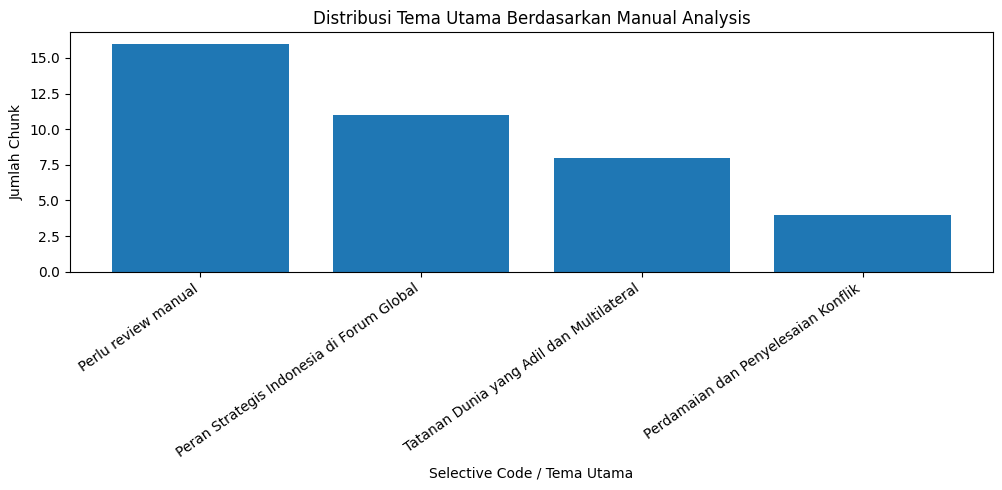

In [14]:
# Visualisasi distribusi selective code
plt.figure(figsize=(10, 5))

plt.bar(
    selective_code_distribution["selective_code"],
    selective_code_distribution["jumlah_chunk"]
)

plt.title("Distribusi Tema Utama Berdasarkan Manual Analysis")
plt.xlabel("Selective Code / Tema Utama")
plt.ylabel("Jumlah Chunk")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 14. Menentukan Tema Dominan

Pada tahap ini, notebook menampilkan tema paling dominan berdasarkan jumlah chunk terbanyak.

Tema dominan ini dapat digunakan sebagai bahan narasi awal dalam presentasi.

In [15]:
# Mengambil tema dominan
dominant_theme = selective_code_distribution.iloc[0]["selective_code"]
dominant_count = selective_code_distribution.iloc[0]["jumlah_chunk"]
dominant_percentage = selective_code_distribution.iloc[0]["persentase"]

print("Tema dominan manual analysis:")
print(f"- Tema       : {dominant_theme}")
print(f"- Jumlah     : {dominant_count} chunk")
print(f"- Persentase : {dominant_percentage}%")

Tema dominan manual analysis:
- Tema       : Perlu review manual
- Jumlah     : 16 chunk
- Persentase : 41.03%


## 15. Interpretasi Hasil Manual Analysis

Berdasarkan hasil manual analysis, pidato Presiden Prabowo pada Sidang Umum PBB ke-80 dapat dibaca sebagai pidato diplomatik yang menekankan posisi Indonesia dalam forum global.

Secara umum, tema-tema yang muncul mencakup:

1. Keadilan global dan solidaritas kemanusiaan.
2. Penguatan multilateralisme dan peran PBB.
3. Perdamaian dan penyelesaian konflik, khususnya isu Palestina dan Gaza.
4. Ketahanan pangan, pembangunan berkelanjutan, perubahan iklim, dan energi.
5. Peran Indonesia sebagai negara berkembang yang aktif dalam diplomasi global.

Hasil manual analysis ini akan digunakan sebagai pembanding terhadap hasil BERTopic pada tahap berikutnya.

In [16]:
# Membuat narasi interpretasi otomatis berdasarkan tema dominan
interpretation_text = f"""
Berdasarkan hasil manual analysis, tema yang paling dominan adalah 
'{dominant_theme}' dengan jumlah {dominant_count} chunk atau sekitar {dominant_percentage}% 
dari keseluruhan chunk yang dianalisis.

Hal ini menunjukkan bahwa pidato memiliki penekanan kuat pada isu tersebut.
Namun, hasil ini tetap perlu dibaca sebagai hasil interpretasi manual berbasis codebook,
sehingga dapat dibandingkan dengan hasil topic modeling menggunakan BERTopic pada tahap berikutnya.
"""

print(textwrap.fill(interpretation_text, width=100))

 Berdasarkan hasil manual analysis, tema yang paling dominan adalah  'Perlu review manual' dengan
jumlah 16 chunk atau sekitar 41.03%  dari keseluruhan chunk yang dianalisis.  Hal ini menunjukkan
bahwa pidato memiliki penekanan kuat pada isu tersebut. Namun, hasil ini tetap perlu dibaca sebagai
hasil interpretasi manual berbasis codebook, sehingga dapat dibandingkan dengan hasil topic modeling
menggunakan BERTopic pada tahap berikutnya.


## 16. Finalisasi Dataframe Manual Analysis

Pada bagian ini, dataframe final disusun dengan kolom yang rapi agar mudah dibaca, dianalisis, dan diekspor.

In [17]:
# Susun urutan kolom final
final_columns = [
    "chunk_id",
    TEXT_COLUMN,
    "char_count",
    "word_count",
    "primary_open_code",
    "secondary_open_codes",
    "axial_code",
    "selective_code",
    "matched_keywords",
    "coding_score",
    "coding_confidence",
    "evidence_quote",
    "researcher_memo"
]

manual_analysis_results = manual_analysis_results[final_columns].copy()

# Rename kolom teks agar konsisten
manual_analysis_results = manual_analysis_results.rename(
    columns={TEXT_COLUMN: "chunk_text"}
)

display(manual_analysis_results.head(10))

print("Ukuran dataframe final:", manual_analysis_results.shape)

,chunk_id,chunk_text,char_count,word_count,primary_open_code,secondary_open_codes,axial_code,selective_code,matched_keywords,coding_score,coding_confidence,evidence_quote,researcher_memo
0,1,"His Excellency Mr. Antoni Guterres, Secretary General of the United Nations; Her Excellency Madam Annalena Baerbock, President of the United Nations General Assembly; His Excel...",602,86,Dukungan terhadap PBB,,Penguatan multilateralisme dan peran PBB,Tatanan Dunia yang Adil dan Multilateral,who,1,rendah,"His Excellency Mr. Antoni Guterres, Secretary General of the United Nations; Her Excellency Madam Annalena Baerbock, President of the United Nations General Assembly; His Excel...",Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
1,2,"We are here first and foremost as fellow human beings - each created equal, endowed with unalienable rights to life, liberty, and the pursuit of happiness. The words of the Uni...",527,80,Diplomasi Indonesia dan Global South,,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,indonesia,1,rendah,"We are here first and foremost as fellow human beings - each created equal, endowed with unalienable rights to life, liberty, and the pursuit of happiness. The words of the Uni...",Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
2,3,"“All men are created equal” was the creed that opened the way to unprecedented global prosperity and dignity. And yet, in our own era of scientific and technological triumphs -...",421,66,Pengalaman kolonialisme dan ketidakadilan,,Keadilan global dan solidaritas kemanusiaan,Tatanan Dunia yang Adil dan Multilateral,apartheid,1,rendah,"“All men are created equal” was the creed that opened the way to unprecedented global prosperity and dignity. And yet, in our own era of scientific and technological triumphs -...",Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
3,4,"My country knows this pain. For centuries, Indonesians lived under colonial domination, oppression, and slavery. We were treated less than dogs in our own homeland.",164,25,Diplomasi Indonesia dan Global South,,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,indonesia,1,rendah,"My country knows this pain. For centuries, Indonesians lived under colonial domination, oppression, and slavery. We were treated less than dogs in our own homeland.",Perlu ditinjau ulang secara manual karena kecocokan keyword rendah.
4,5,"We Indonesians know what it means to be denied justice and what it means to live in apartheid, to live in poverty, and to be denied equal opportunity. We also knew what solidar...",346,60,Diplomasi Indonesia dan Global South,Pengalaman kolonialisme dan ketidakadilan,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,indonesia,2,sedang,"We Indonesians know what it means to be denied justice and what it means to live in apartheid, to live in poverty, and to be denied equal opportunity. We also knew what solidar...",Kode awal sesuai berdasarkan kemunculan keyword dan konteks chunk.
5,6,"Decisions made here based on human solidarity - by the Security Council and this Assembly - gave Indonesia independence international legitimacy, opened doors, and supported ou...",581,85,Dukungan terhadap PBB,Diplomasi Indonesia dan Global South,Penguatan multilateralisme dan peran PBB,Tatanan Dunia yang Adil dan Multilateral,"unicef, fao, who",3,sedang,"Decisions made here based on human solidarity - by the Security Council and this Assembly - gave Indonesia independence international legitimacy, opened doors, and supported ou...",Kode awal sesuai berdasarkan kemunculan keyword dan konteks chunk.
6,7,"Everyday we witness suffering, genocide, and a blatant disregard for international law and human decency. In the face of these challenges, we must not give up. As the United Na...",224,37,Perlu review manual,,Perlu review manual,Perlu review manual,,0,rendah,"Everyday we witness suffering, genocide

Ukuran dataframe final: (39, 13)


## 17. Export Hasil Manual Analysis

Hasil manual analysis disimpan ke:

`data/processed/manual_analysis_results.csv`

File ini akan digunakan pada tahap berikutnya untuk dibandingkan dengan hasil BERTopic.

In [18]:
# Export hasil manual analysis
manual_analysis_results.to_csv(
    OUTPUT_RESULT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Hasil manual analysis berhasil disimpan.")
print("Lokasi file:", OUTPUT_RESULT_PATH)
print("Jumlah data:", manual_analysis_results.shape)

Hasil manual analysis berhasil disimpan.
Lokasi file: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\data\processed\manual_analysis_results.csv
Jumlah data: (39, 13)


## 18. Kesimpulan Tahap 02

Tahap manual analysis telah menghasilkan beberapa output utama:

1. Template manual coding:
   - `data/processed/manual_coding_template.csv`

2. Hasil manual analysis:
   - `data/processed/manual_analysis_results.csv`

3. Struktur coding:
   - Open Coding
   - Axial Coding
   - Selective Coding

4. Distribusi tema manual yang dapat digunakan sebagai baseline pembanding terhadap BERTopic.

Secara metodologis, tahap ini penting karena BERTopic akan menghasilkan topic modeling berbasis machine learning, sedangkan manual analysis menghasilkan interpretasi berbasis pembacaan manusia.